# PRG Toolbox Tutorial: what does PRG do?
### Walking through the Phenomenological Renormalization Group (PRG) Loop

This notebook provides a "under-the-hood" look at the `prg-toolbox`. We will manually visualize the coarse-graining routine step-by-step and use it to demonstrate how statistical observables are tracked across scaling iterations.

---

First, let's access some data and see how it looks. In this example, we'll get data from simulations of the multi-area model from Schmidt et al. (2018) [1]

✔ Ready: /home/miranda-castro/Documents/projects/prg_toolbox/example_notebooks/example_data_directory/spikes-V4-5E.gdf
There is a mixture of irregular and coordinated activity in the data.


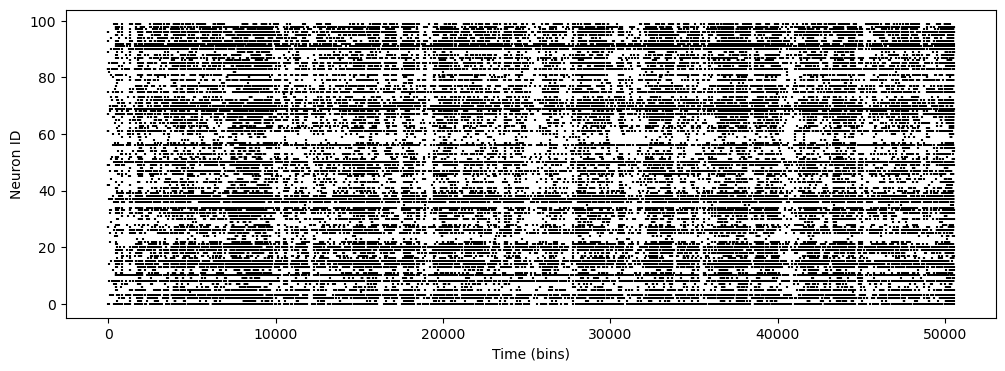

In [12]:
import prg_toolbox as prg
import os
import numpy as np
import matplotlib.pyplot as plt

# Download spiking data and return the path to the folder
file_path = prg.datasets.get_spike_data(files=['5E']) 

# Load the timestamps from the downloaded file
# We will use just a subsample of the full data 
data_format = 'tabular'
data_timestamps = prg.tools._load_timestamps(file_path, format=data_format)
timestamps = prg.tools._pick_random_sample_from_timestamps(data_timestamps, sample_size=4096)

# Working with binary variables is the standard approach in PRG
binary_array = prg.tools.binarize_data(timestamps, data_format=data_format)

# Let's have a look at how the binary array looks like
rows_to_plot = 100
subset = binary_array[:rows_to_plot, :]
y_indices, x_indices = np.nonzero(subset)

plt.figure(figsize=(12, 4))
plt.scatter(x_indices, y_indices, s=1, c='black', marker='|')
plt.xlabel('Time (bins)')
plt.ylabel('Neuron ID')
print('There is a mixture of irregular and coordinated activity in the data.')

### Next, we run the coarse-graining procedure on our binary data. 

At every step, we select the most correlated pair of neuron and create a new variable which is their summed activity. After repeating the process for the remaining neurons, we get $N/2$ variables with 2 neurons inside. Then, we repeat, obtaining block variables made of $C_{size} = 4, 8, ... 2^k$ neurons after $k$ steps. Let's visualize this: 

In [13]:
# Create the object that stores coarse grained variables
CG_variables = prg.CGVariables(binary_array, cluster_method='pearson', rg_steps=8)

print(f'The coarsed grained variables object has the attributes:', CG_variables.__dict__.keys())

The coarsed grained variables object has the attributes: dict_keys(['cluster_method', 'rg_steps', 'time_window', 'CG_timeseries', 'CG_correlation_matrices', 'CG_cluster_idx'])


With the CG_cluster_idx attribute, we keep track of which blocks compose each larger block:

In [14]:
def print_clusters(highest_level = 4, neuron_tracked = 0):
    for i in np.flip(1 + np.arange(highest_level)):
        print(f'Iteration {i} \n------------------')
        print('The cluster was composed of the following neurons:')
        tracked_idx = next(idx for idx, clu in enumerate(CG_variables.CG_cluster_idx[i]) if neuron_tracked in clu)
        print(CG_variables.CG_cluster_idx[i][tracked_idx])
        clu_size = len(CG_variables.CG_cluster_idx[i][tracked_idx])
        previous_clu1 = np.where(CG_variables.CG_cluster_idx[i-1] == CG_variables.CG_cluster_idx[i][tracked_idx][0])[0][0]
        previous_clu2 = np.where(CG_variables.CG_cluster_idx[i-1] == CG_variables.CG_cluster_idx[i][tracked_idx][int(clu_size/2)]) [0][0]
        print('\nWhich came from the previous clusters:')
        print(CG_variables.CG_cluster_idx[i-1][previous_clu1])
        print(CG_variables.CG_cluster_idx[i-1][previous_clu2])
        print('\n')

print_clusters()

Iteration 4 
------------------
The cluster was composed of the following neurons:
[ 682 3063  314 3743 2468 3771 1528 3373 2860 3227    0 2405 1425 4046
 1715  628]

Which came from the previous clusters:
[ 682 3063  314 3743 2468 3771 1528 3373]
[2860 3227    0 2405 1425 4046 1715  628]


Iteration 3 
------------------
The cluster was composed of the following neurons:
[2860 3227    0 2405 1425 4046 1715  628]

Which came from the previous clusters:
[2860 3227    0 2405]
[1425 4046 1715  628]


Iteration 2 
------------------
The cluster was composed of the following neurons:
[2860 3227    0 2405]

Which came from the previous clusters:
[2860 3227]
[   0 2405]


Iteration 1 
------------------
The cluster was composed of the following neurons:
[   0 2405]

Which came from the previous clusters:
0
2405




We could imagine this process visually as something like this (here, the neuron positions are chosen randomly):

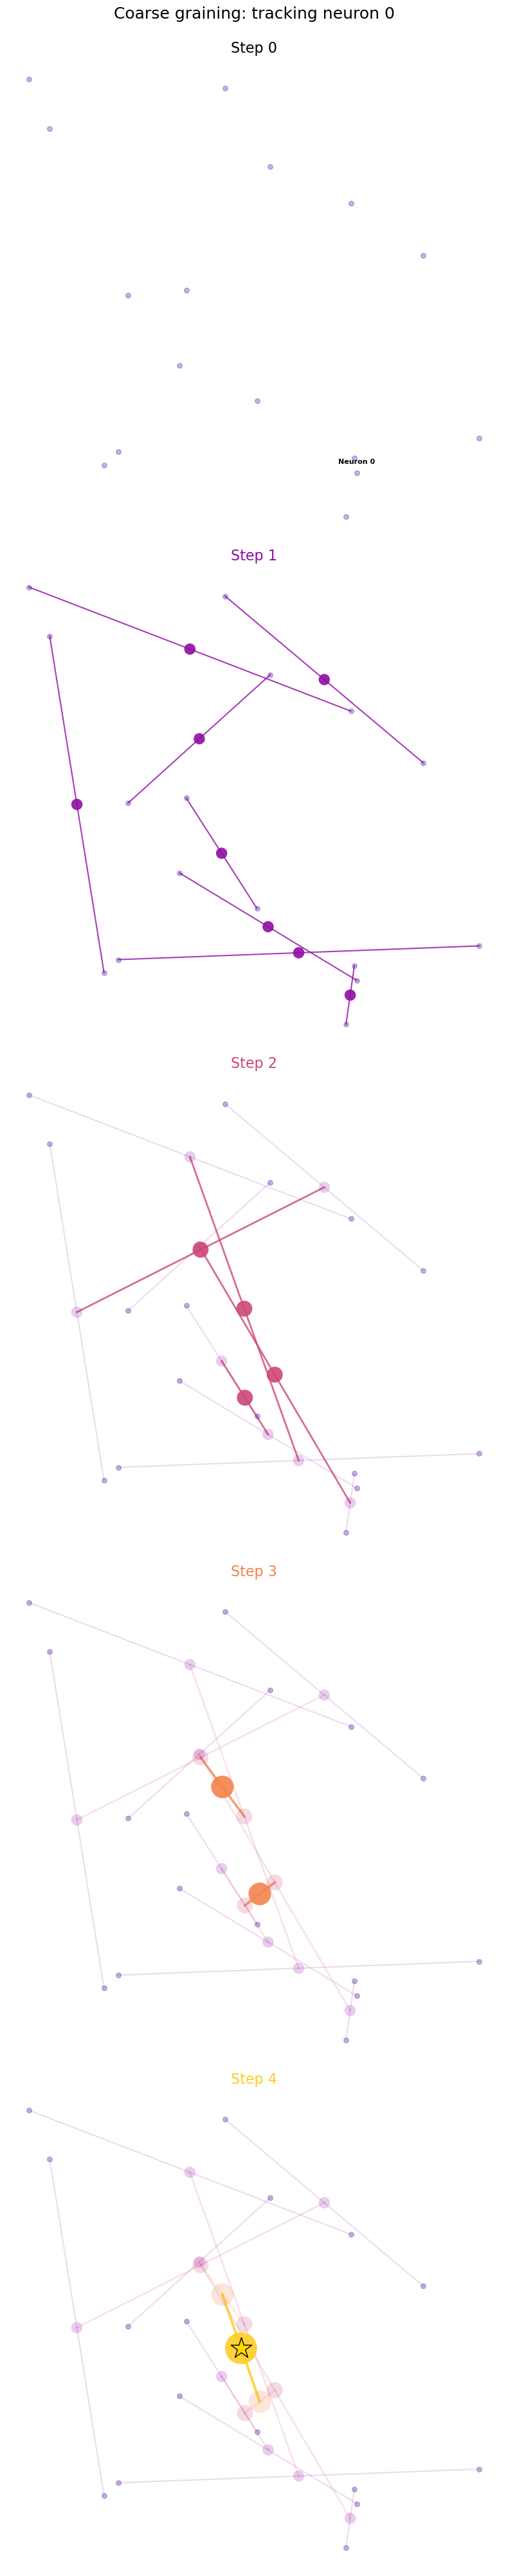

In [15]:
prg.plot.plot_constellation_steps(CG_variables, highest_level=4, neuron_tracked=0)

The merging of timeseries allow block variables to assume increasing values:

This function is just an example with toy data. 
In real data it is not necessarily so easy to 
visualize in a plot which segments of timeseries 
pairs will drive their correlation up.


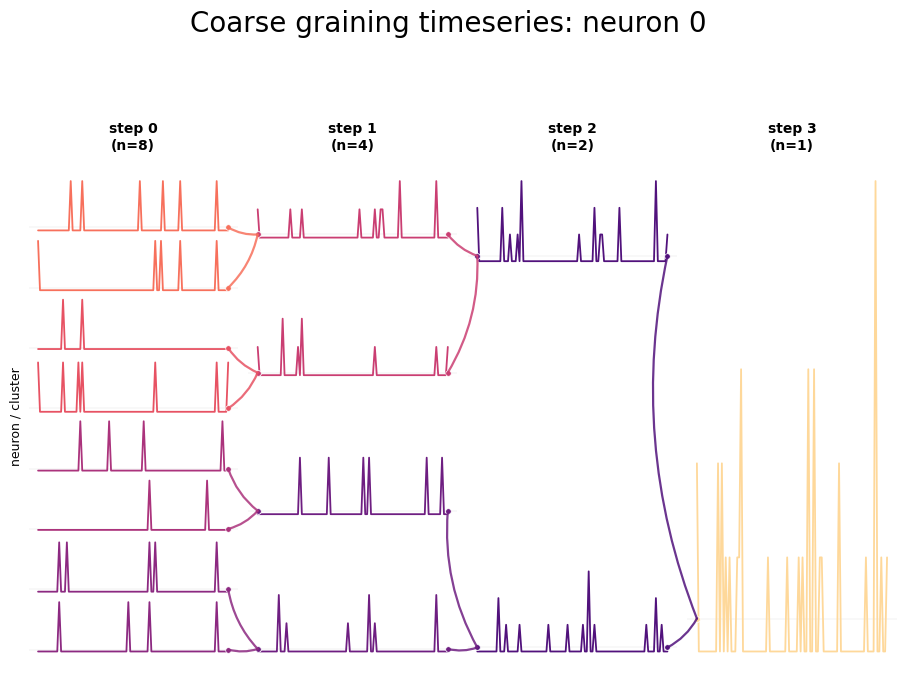

In [16]:
print("This function is just an example with toy data. \nIn real data it is not necessarily so easy to \nvisualize in a plot which segments of timeseries \npairs will drive their correlation up.")
prg.plot.plot_prg_cascade(top_level=3, time_bins=100)

### With the coarse grained data, we can calculate several observables and track their scaling across steps.

For each $C_{size}$, we calculate the observable for the variables at that coarse graining level and look for power-law behavior, our signature of scale invariance. 

Let's look at them one by one:

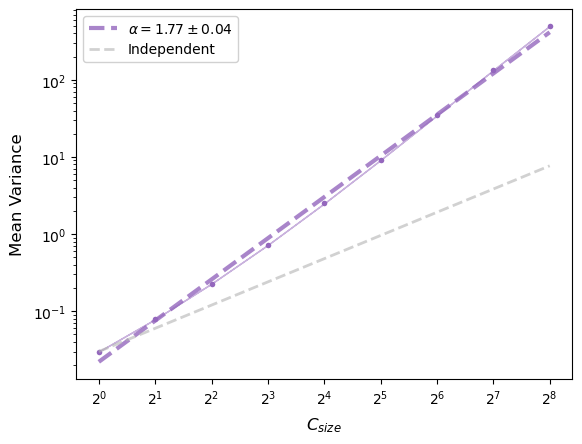

In [17]:
"""
The method that calculates the observable automatically reads
the necessary parameters (such as rg_steps) from the CGVariables
class.
"""
mvar = prg.mean_variance(CG_variables)
"""
Plotting functions also have some built-in defaults.
"""
prg.plot.plot_mean_variance(mvar)

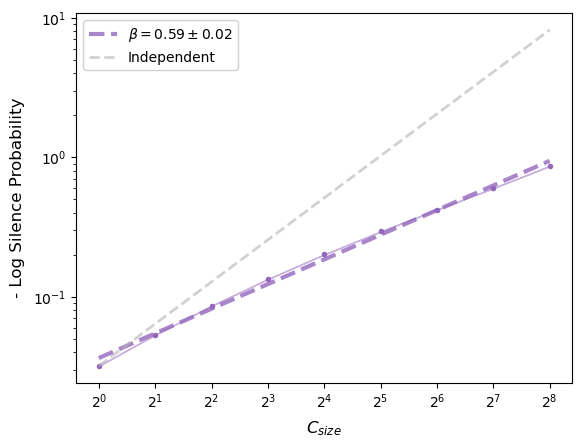

In [18]:
sprob = prg.log_silence_probability(CG_variables)
prg.plot.plot_log_silence_probability(sprob)

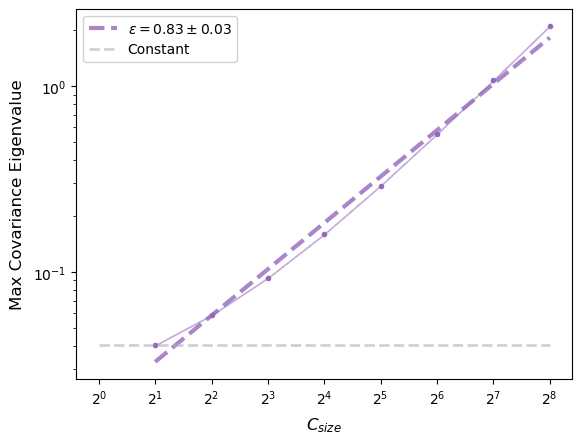

In [19]:
maxeval = prg.max_covariance_eigenvalue(CG_variables)
prg.plot.plot_max_covariance_eigenvalue(maxeval)

In the case of the covariance spectrum, beyond the power-law decay of the eigenvalues we can also look for the shape collapse of different curves when we rescale the eigenvalue ranks to $rank/N$.

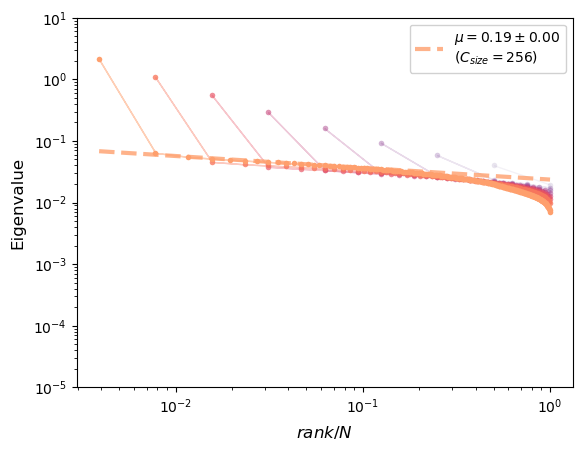

In [20]:
spec = prg.covariance_spectrum(CG_variables)
prg.plot.plot_covariance_spectrum(spec)

Dynamical observables: mean autocorrelation function and characteristic decay time

*Note: Computing all the autocorrelations from coarse grained variables is generally more computationally intensive; 
For the sake of keeping the example quick, let's demonstrate it on a lower time resolution:

/home/miranda-castro/Documents/projects/prg_toolbox/prg_toolbox/coarse_graining.py:344: UserWarning: Number of variables is greater than number of samples. Correlation measurements may be unreliable.
  warnings.warn("Number of variables is greater than number of samples. Correlation measurements may be unreliable.")


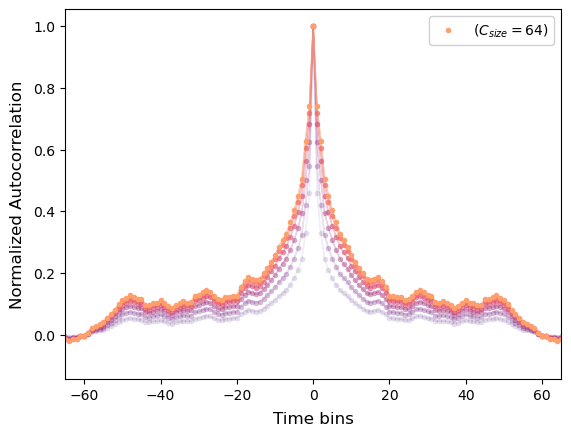

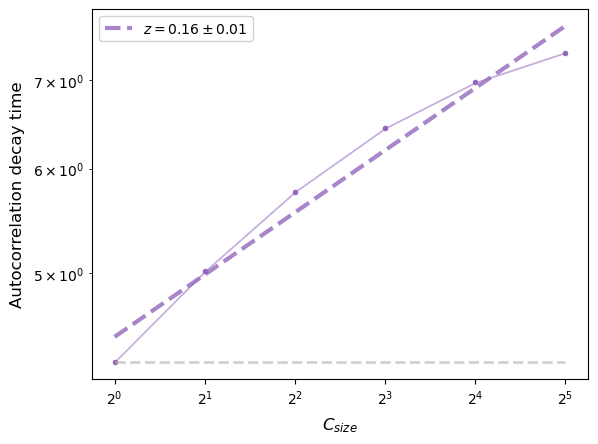

In [21]:
# # Slicing just a small portion of the data
binary_array_for_acf = prg.tools.binarize_data(timestamps, data_format=data_format, binsize_ms=20)
CG_variables_for_acf = prg.CGVariables(binary_array_for_acf, rg_steps=6)
# -------------------------------------------

acf = prg.autocorrelation_function(CG_variables_for_acf)
fig = plt.figure()
prg.plot.plot_autocorrelation_function(acf)

decaytime = prg.decay_time(CG_variables_for_acf)
fig = plt.figure()
prg.plot.plot_decay_time(decaytime)

For the normalized activity distribution, we wish to see if coarse graining leads the activity to a non-Gaussian form. 
Note: the plot algorithm automatically plots the Gaussian with same mean and std. deviation of the data

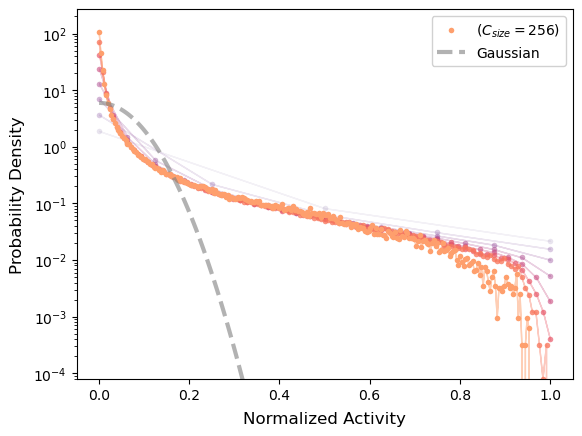

In [22]:
actdist = prg.activity_distribution(CG_variables)
prg.plot.plot_activity_distribution(actdist)

#### Validating results with surrogate data:

One form of validating your results and assuring that they do not come from any artifacts in your data is to compare them with the results for surrogate (shuffled) data. A common option is to shuffle each timeseries inter-spike interval (isi) sequence and reconstruct the data. This preserves the overall level of activity but breaks time correlation between variables. See the example: 

Surrogate data generated.


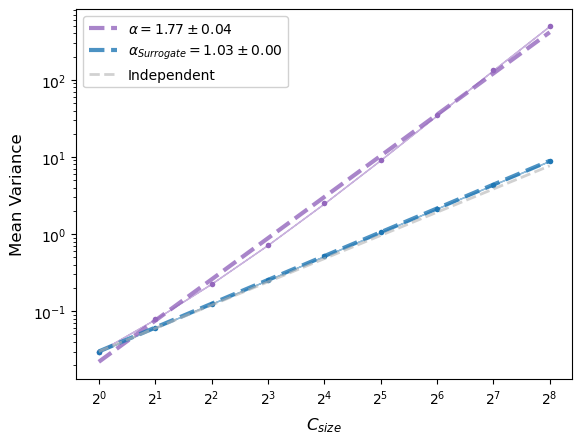

In [25]:
timestamps_surr = prg.tools._shuffle_isi_timestamps(timestamps)
print('Surrogate data generated.')
binary_surr = prg.tools.binarize_data(timestamps_surr, data_format=data_format)
CG_variables_surr = prg.CGVariables(binary_surr, rg_steps=8)

mvar_surr = prg.mean_variance(CG_variables_surr)
prg.plot.plot_mean_variance(data=mvar, surrogate_data=mvar_surr) 

## 🧭 Wrapping up: PRG Scaling Exponents

The Phenomenological Renormalization Group (PRG) analysis, in standard applications, yields five scaling exponents that characterize the system's approach to a non-trivial fixed point.

### The Five Exponents

| Exponent | Observable | Notes |
| --- | --- | --- |
| **$\alpha$** | Mean Variance | Under certain conditions, $\alpha$, $\beta$ and $\epsilon$ can be analytically (linearly) related to one another [2]. |
| **$\beta$** | -Log(Silence Prob.) |  |
| **$\epsilon$** | First Covariance Eig. ||
| **$\mu$** | Covariance Spectrum | Although its fitting to data is less straightfoward, its scaling can be derivated analitically in an analogous way to the original Wilsonian RG [3].|
| **$z$** | Autocorrelation Decay | *The Dynamical Exponent:* explicitly involves time, and may or not display non trivial scaling independently of the others or even the opposite trend [4]. |

###  Non-Gaussianity
As an additional signature, one may inspect if the activity distribution of coarse grained variables converge to a non-Gaussian form across iterations. Since real data is prone to finite-size effects, the activity distribution can also be used as a guide to discard parameter choices that lead to pathological dynamics.

Further examples on how to tweak the toolbox for a specific case (style plots, run time/subsampled averaged, use automated pipelines for large data) are available in the repository.

---

References:
1.  Schmidt, M., Bakker, R., Shen, K., Bezgin, G., Diesmann, M., van Albada, S. J (2018).
    A multi-scale layer-resolved spiking network model of resting-state dynamics in macaque visual cortical areas
    *PLOS Computational Biology*, 14(10).
    DOI: [10.1371/journal.pcbi.1006359](https://doi.org/10.1371/journal.pcbi.1006359 )
2. Castro, D. M., Raposo, E. P., Copelli, M., & Santos, F. A. N. (2025). 
    Interdependent scaling exponents in the human brain. 
    *Physical Review Letters*, 135(19), 198401. 
    DOI: [10.1103/PhysRevLett.135.198401](https://doi.org/10.1103/lvwj-hjr3)
3. Bradde, S., Bialek, W (2017).
    PCA Meets RG.  
    *J Stat Phys*, 167. 
    DOI: [10.1007/s10955-017-1770-6](https://doi.org/10.1007/s10955-017-1770-6)
4. Cambrainha, G. G., Castro, D. M., Gollo, L. L., Carelli, P. V., Copelli, M. (2026).
    Hierarchical organization of critical brain dynamics
     arXiv preprint.   
    DOI: [10.48550/arXiv.2604.21832](https://doi.org/10.48550/arXiv.2604.21832)